# pred-3: fusing what you discuss with how you email

pred-2 left two separate windows onto a person's rank. The metadata window (how
someone emails: volume, reach, who writes to them) put executive status at
AUC 0.80. The content window (what they discuss, read off the thread
annotations) reached 0.73 on its own. They look like two views of the same
thing. This notebook asks whether they are: does joining them predict rank
better than either alone, and if so, what does content see that the metadata
misses?

Everything runs on one fixed set of 135 mailbox owners so the three feature
blocks are directly comparable. The targets stay external (the Shetty-Adibi job
titles), the scaler sits inside every fold, and a permutation test decides
whether the fused model's edge is more than fitting noise.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "pred-2" / "thread_annotations.parquet").exists():
            return base
    raise FileNotFoundError("thread_annotations.parquet not found")
ROOT = find_root()
CLEAN, REFS = ROOT / "eda-5" / "clean", ROOT / "eda-5" / "refs"
PLOTS = ROOT / "pred-3" / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#6a3d9a"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

## Three feature blocks on one set of people

The metadata block is the twelve behavioural features from pred-1 and pred-2,
rebuilt unchanged. The content block is read entirely off the LLM thread
annotations and never touches the job titles: the mix of the eight thread
categories a person takes part in, how often those threads name a regulator, a
counterparty, an Enron desk or a contract instrument, and the rate at which they
carry a request, reach a decision, or end up resolved or left open. Sixteen
content features in all. A person counts as taking part in a thread when they
sent at least one message in it.

The two blocks are built on the same base (owners who authored at least thirty
messages, assistants' delegate sends removed) and then narrowed to those with at
least ten annotated threads, so the content mix is not estimated from a handful
of conversations. That leaves 135 people, every one of whom carries a job
title.

In [2]:
msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")
roles = pd.read_parquet(CLEAN / "people_roles.parquet").set_index("owner")
ann = pd.read_parquet(ROOT / "pred-2" / "thread_annotations.parquet")
DEL = set(pd.read_csv(REFS / "assistant_delegates.csv", sep=";")["assistant_addr"])

# --- metadata block: the twelve features, exactly as in pred-2 ---
authored = msg[msg["sender_person"].notna()]
authored = authored[~authored["from_addr_norm"].isin(DEL)].copy()
keep0 = sorted(authored.groupby("sender_person").size().pipe(lambda s: s[s >= 30]).index)
a = authored[authored["date_plausible"] & authored["date"].notna()].copy()
a["wknd"] = a["date"].dt.dayofweek >= 5
g, ag = authored.groupby("sender_person"), a.groupby("sender_person")
F = pd.DataFrame(index=keep0)
F["n_sent"]        = g.size()
F["med_len"]       = g["body_chars"].median()
F["mean_recip"]    = g["recipient_count"].mean()
F["ext_ratio"]     = g["has_external_recipient"].mean()
F["cc_ratio"]      = g["cc_count"].sum() / g["recipient_count"].sum().replace(0, np.nan)
F["broadcast"]     = authored.assign(b=authored["recipient_count"] > 5).groupby("sender_person")["b"].mean()
F["root_ratio"]    = g["is_thread_root"].mean()
F["wknd_ratio"]    = ag["wknd"].mean()
F["active_months"] = (ag["date"].max() - ag["date"].min()).dt.days / 30.44
F["del_rate"]      = msg.assign(d=msg["folder_group"].eq("deleted")).groupby("mailbox_owner")["d"].mean().reindex(keep0)
ei = rcp.merge(msg[["message_id", "sender_person"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"] & ~ei["recipient_is_list"]
        & ~ei["is_self"] & ei["sender_person"].notna() & ei["recipient_person"].notna()
        & (ei["sender_person"] != ei["recipient_person"])]
F["out_deg"] = ei.groupby("sender_person")["recipient_person"].nunique().reindex(keep0)
F["in_deg"]  = ei.groupby("recipient_person")["sender_person"].nunique().reindex(keep0)
F = F.reindex(keep0).fillna(F.median())
for c in ["n_sent", "med_len", "mean_recip", "active_months", "out_deg", "in_deg"]:
    F[c] = np.log1p(F[c])
META_FEATS = list(F.columns)

# --- content block: read off the thread annotations only ---
au = authored[["thread_id", "sender_person"]]
j = au[au.sender_person.isin(keep0)].merge(
        ann[["thread_id", "category", "outcome", "has_request", "has_decision"]], on="thread_id")
nthr = j.groupby("sender_person").thread_id.nunique()
content_owners = nthr[nthr >= 10].index

cat_mix = pd.crosstab(j.sender_person, j.category, normalize="index")     # 8 category shares
CATS = list(cat_mix.columns)

TYPE = {"ferc": "reg", "cpuc": "reg", "california": "reg", "calpx": "reg", "caiso": "reg", "cal-iso": "reg",
        "ercot": "reg", "dynegy": "cpty", "pg&e": "cpty", "el paso": "cpty", "sce": "cpty", "aep": "cpty",
        "ubs": "cpty", "ge": "cpty", "prebon": "cpty", "ena": "desk", "enrononline": "desk", "eol": "desk",
        "ees": "desk", "epmi": "desk", "sitara": "desk", "netco": "desk", "enpower": "desk", "nng": "desk",
        "hpl": "desk", "transwestern": "desk", "enron": "desk", "enron north america": "desk", "rac": "desk",
        "isda": "instr", "isda master agreement": "instr", "master agreement": "instr", "nymex": "instr",
        "direct access": "instr"}
def thread_types(s):
    out = set()
    try:
        for e in json.loads(s):
            t = TYPE.get(str(e).strip().lower())
            if t: out.add(t)
    except Exception:
        pass
    return out
et = ann[["thread_id", "entities"]].copy()
et["types"] = et["entities"].apply(thread_types)
for t in ["reg", "cpty", "desk", "instr"]:
    et[f"ent_{t}"] = et["types"].apply(lambda s, t=t: t in s)
jt = au[au.sender_person.isin(keep0)].merge(
        et[["thread_id", "ent_reg", "ent_cpty", "ent_desk", "ent_instr"]], on="thread_id")
ent_rate = jt.groupby("sender_person")[["ent_reg", "ent_cpty", "ent_desk", "ent_instr"]].mean()

j2 = j.assign(resolved=j["outcome"].eq("resolved"), open=j["outcome"].eq("open"))
act = j2.groupby("sender_person").agg(req=("has_request", "mean"), dec=("has_decision", "mean"),
                                      resolved=("resolved", "mean"), open=("open", "mean"))
content = cat_mix.join(ent_rate).join(act)
CONTENT_FEATS = list(content.columns)

# --- common set, matrices, external targets ---
common = sorted(set(keep0) & set(content_owners) & set(roles.index))
Xm = F.loc[common, META_FEATS].values
Xc = content.loc[common, CONTENT_FEATS].fillna(content[CONTENT_FEATS].median()).values
Xf = np.hstack([Xm, Xc])
y_exec = roles["is_executive"].reindex(common).astype(int).values
y_rank = roles["seniority_rank"].reindex(common).astype(float).values
names = roles["display_name"].reindex(common).values
blocks = {"metadata": Xm, "content": Xc, "fused": Xf}
COL3 = {"metadata": PURPLE, "content": BLUE, "fused": GREEN}
LBL = {"metadata": "how you email<br>(metadata, 12)", "content": "what you discuss<br>(content, 16)",
       "fused": "both<br>(fused, 28)"}
PRETTY = {"deal-contract": "deals & contracts", "internal-admin": "internal / admin", "social": "social",
    "trading-risk": "trading & risk", "scheduling-logistics": "scheduling", "legal-regulatory": "legal / regulatory",
    "report-fyi": "reports / FYI", "california-energy": "California crisis",
    "ent_reg": "names a regulator", "ent_cpty": "names a counterparty", "ent_desk": "names an Enron desk",
    "ent_instr": "names a contract / instrument", "req": "carries a request", "dec": "reaches a decision",
    "resolved": "ends resolved", "open": "left open",
    "n_sent": "messages sent", "med_len": "median body length", "mean_recip": "recipients per message",
    "ext_ratio": "share external", "cc_ratio": "Cc share", "broadcast": "share to >5 people",
    "root_ratio": "thread-opening share", "wknd_ratio": "weekend share", "active_months": "active months",
    "del_rate": "mailbox deletion rate", "out_deg": "people written to", "in_deg": "people writing in"}

def oof_auc(X, y, rs):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
    return roc_auc_score(y, cross_val_predict(clf, X, y, cv=StratifiedKFold(10, shuffle=True, random_state=rs),
                                              method="predict_proba")[:, 1])
def oof_rho(X, y, rs):
    reg = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20)))
    return spearmanr(y, cross_val_predict(reg, X, y, cv=KFold(10, shuffle=True, random_state=rs))).statistic

print(f"common owners {len(common)}  |  metadata {Xm.shape[1]}d  content {Xc.shape[1]}d  fused {Xf.shape[1]}d")
print(f"executives {int(y_exec.sum())}/{len(common)} (base {y_exec.mean():.3f});  "
      f"seniority ranks {sorted(set(y_rank.astype(int)))}")

common owners 135  |  metadata 12d  content 16d  fused 28d
executives 40/135 (base 0.296);  seniority ranks [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


## How well each window predicts rank

Each block is scored by repeated ten-fold cross-validation: forty shuffles of the
folds, the scaler refit inside every one, giving a spread rather than a single
lucky number. To compare a binary call against an ordinal one fairly, both go on
the same rank-skill scale where zero is chance and one is perfect: for executive
status that is `2 x AUC - 1`, for the seniority ladder it is the Spearman
correlation between predicted and true rank. The two panels share that axis, so a
taller bar genuinely means a stronger prediction. Bars are the mean over the
forty repeats, whiskers the middle 95%, and the label over each bar gives the
result in its own native units.

metadata   AUC 0.790 [0.773,0.806]   rho 0.488 [0.455,0.518]
content    AUC 0.783 [0.763,0.798]   rho 0.391 [0.358,0.421]
fused      AUC 0.829 [0.805,0.849]   rho 0.498 [0.461,0.526]
fused-minus-metadata: AUC +0.039 [+0.015,+0.057]   rho +0.010 [-0.037,+0.037]


/tmp/ipykernel_1513829/586013317.py:40: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


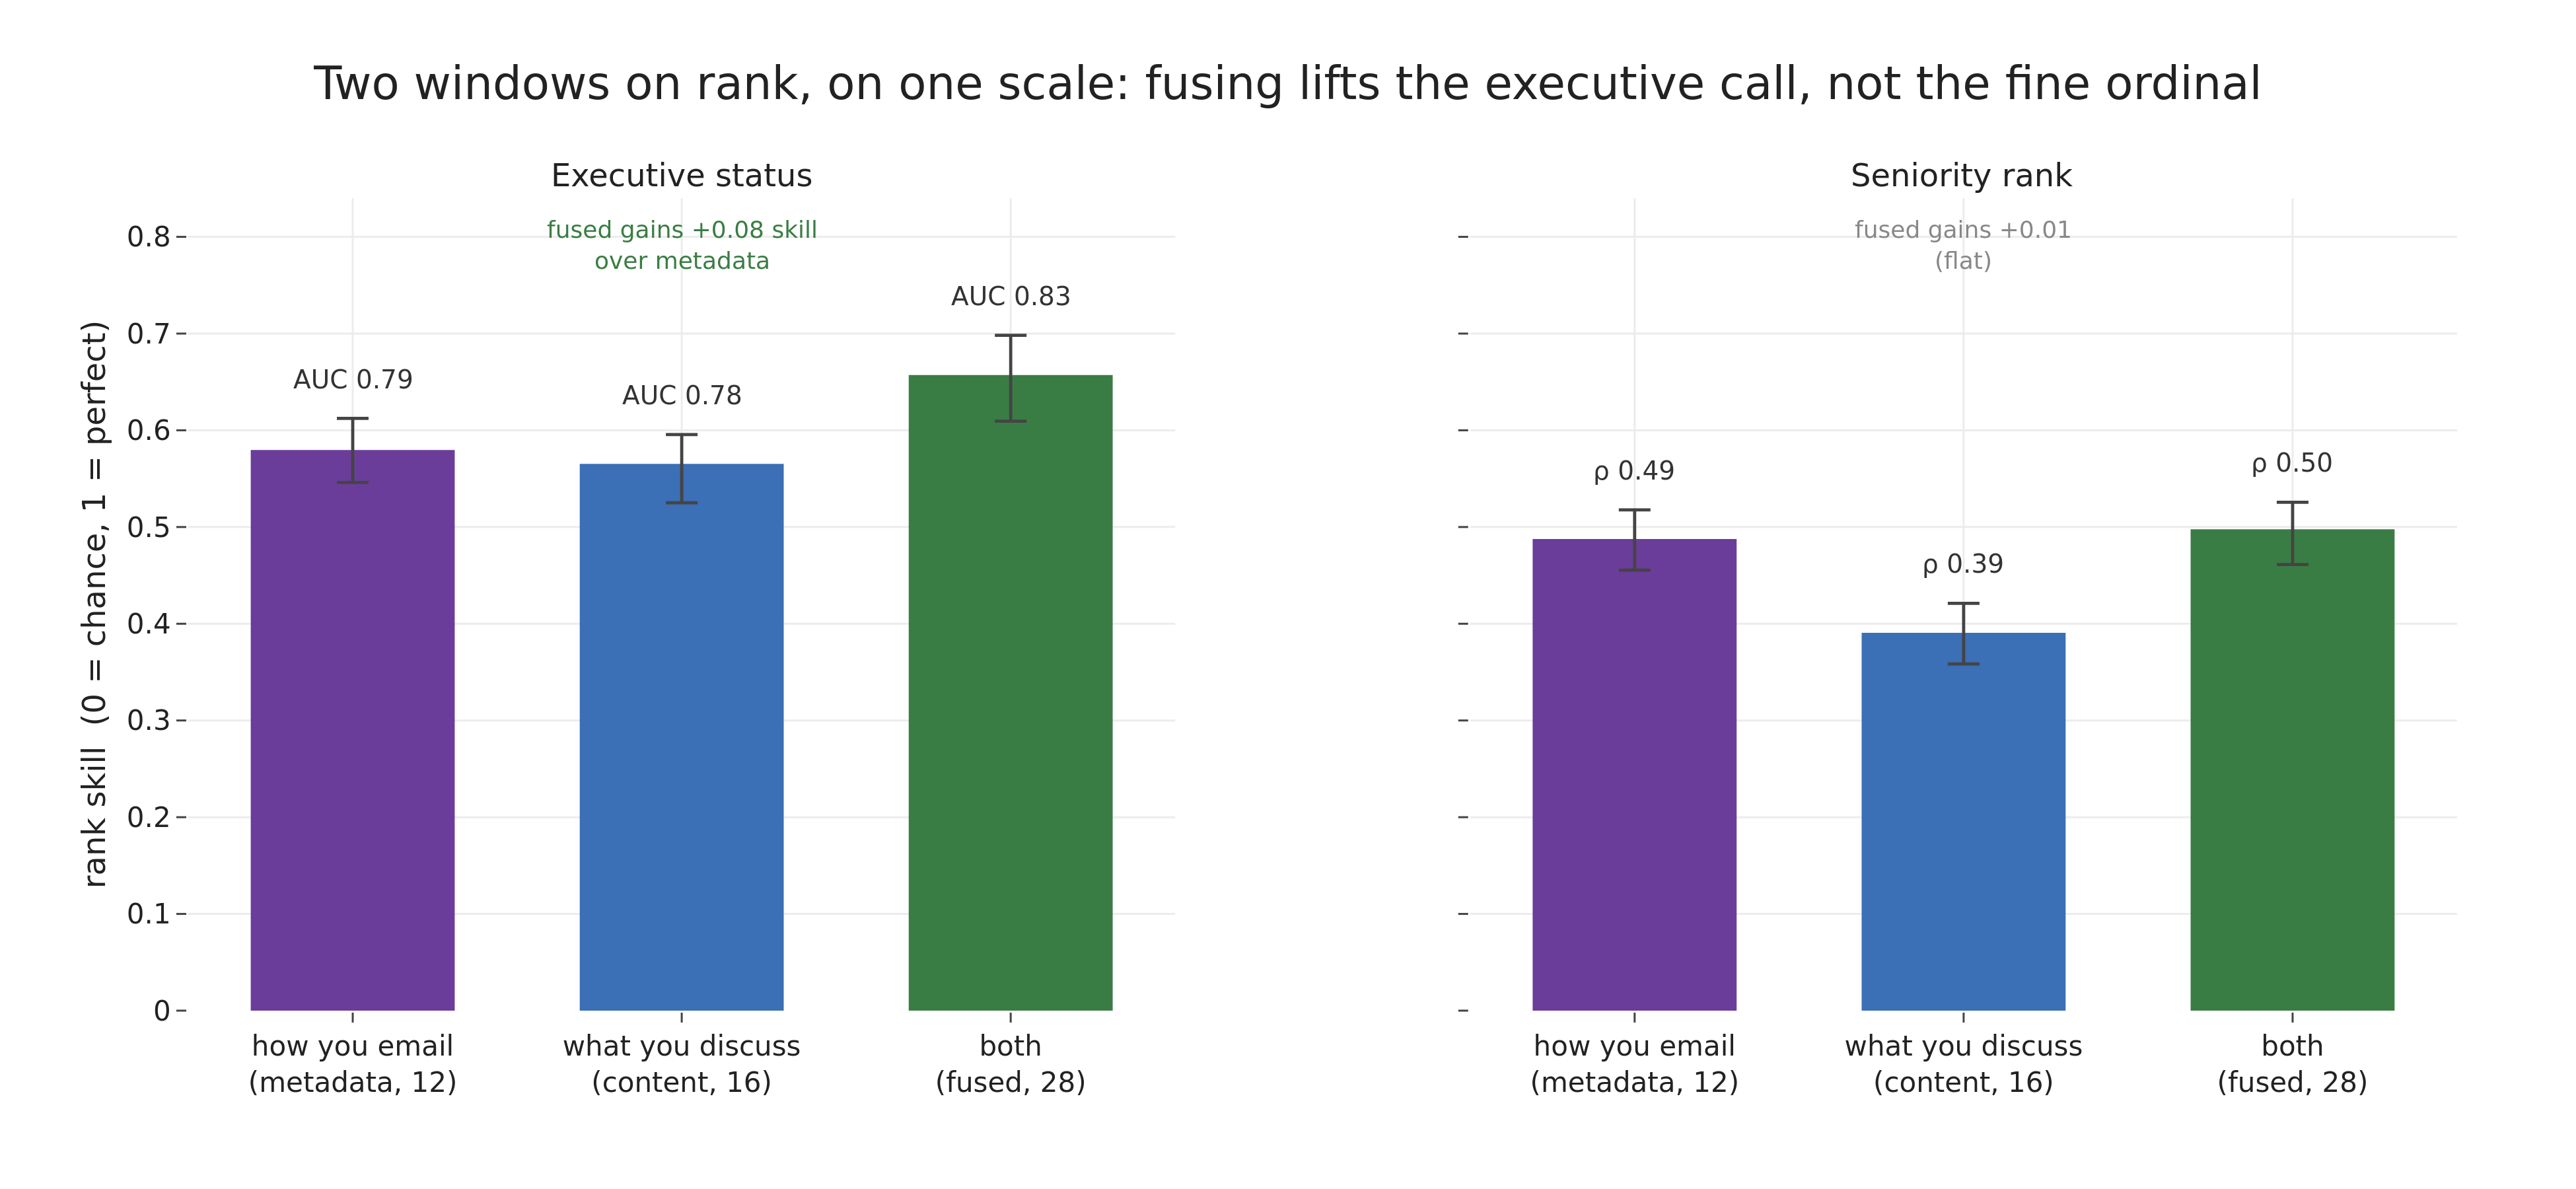

In [3]:
R = 40
rep_auc = {k: np.array([oof_auc(X, y_exec, r) for r in range(R)]) for k, X in blocks.items()}
rep_rho = {k: np.array([oof_rho(X, y_rank, r) for r in range(R)]) for k, X in blocks.items()}
order3 = ["metadata", "content", "fused"]
d_auc = rep_auc["fused"] - rep_auc["metadata"]
d_rho = rep_rho["fused"] - rep_rho["metadata"]
for k in order3:
    print(f"{k:9s}  AUC {rep_auc[k].mean():.3f} [{np.percentile(rep_auc[k],2.5):.3f},{np.percentile(rep_auc[k],97.5):.3f}]"
          f"   rho {rep_rho[k].mean():.3f} [{np.percentile(rep_rho[k],2.5):.3f},{np.percentile(rep_rho[k],97.5):.3f}]")
print(f"fused-minus-metadata: AUC {d_auc.mean():+.3f} [{np.percentile(d_auc,2.5):+.3f},{np.percentile(d_auc,97.5):+.3f}]"
      f"   rho {d_rho.mean():+.3f} [{np.percentile(d_rho,2.5):+.3f},{np.percentile(d_rho,97.5):+.3f}]")

exec_sk = {k: 2 * rep_auc[k] - 1 for k in order3}     # both on a 0=chance, 1=perfect rank-skill scale
sen_sk  = {k: rep_rho[k] for k in order3}
def stat(arr):
    m = arr.mean(); return m, np.percentile(arr, 97.5) - m, m - np.percentile(arr, 2.5)

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.13, shared_yaxes=True,
    subplot_titles=["Executive status", "Seniority rank"])
for col, sk, rep, native in [(1, exec_sk, rep_auc, "AUC"), (2, sen_sk, rep_rho, "ρ")]:
    ms = [stat(sk[k]) for k in order3]
    fig.add_trace(go.Bar(x=[LBL[k] for k in order3], y=[m[0] for m in ms],
        marker_color=[COL3[k] for k in order3], width=0.62,
        error_y=dict(type="data", symmetric=False, array=[m[1] for m in ms], arrayminus=[m[2] for m in ms],
                     color="#444", thickness=1.6, width=8), showlegend=False), row=1, col=col)
    for k, m in zip(order3, ms):
        fig.add_annotation(x=LBL[k], y=m[0] + m[1] + 0.04, text=f"{native} {rep[k].mean():.2f}",
            showarrow=False, font=dict(size=13, color="#333"), row=1, col=col)
fig.update_yaxes(title_text="rank skill  (0 = chance, 1 = perfect)", range=[0, 0.84], row=1, col=1)
fig.update_yaxes(range=[0, 0.84], row=1, col=2)
fig.add_annotation(x=LBL["content"], y=0.79, text=f"fused gains +{2*d_auc.mean():.02f} skill<br>over metadata",
    showarrow=False, font=dict(size=12, color=GREEN), row=1, col=1)
fig.add_annotation(x=LBL["content"], y=0.79, text=f"fused gains +{d_rho.mean():.02f}<br>(flat)",
    showarrow=False, font=dict(size=12, color="#888"), row=1, col=2)
fig.update_layout(title="Two windows on rank, on one scale: fusing lifts the executive call, not the fine ordinal",
    bargap=0.32)
save_fig(fig, "f1_skill.png", w=1300, h=600, margin=dict(l=95, r=60, t=100, b=90))

The executive call is where fusing pays off. Metadata alone scores about 0.79
AUC and content alone about 0.78, but together they reach roughly 0.83, and the
gain holds across every one of the forty fold-shuffles, so the 95% band on the
difference clears zero. The seniority ladder tells the opposite story: metadata
already reaches a rank correlation near 0.49, content trails at 0.39, and adding
content moves the fused model by about a hundredth, well inside the noise.
Metadata saturates the fine ordinal on its own; content has something to add
only at the executive boundary.

## Does content add anything beyond metadata?

The band on the difference suggests it does, for the executive call. Two checks
follow. The first fixes one ten-fold split, holds the metadata fixed, and
shuffles the content rows a thousand times, so each person keeps their own
metadata but is handed a stranger's content; if content carries nothing new, the
fused model should not beat metadata once content is scrambled. That null is
printed in the cell output and noted above the chart.

The chart looks at where the gain lives in the weights. For each of the
twenty-eight features it puts the coefficient from its own solo model (the
metadata-only or content-only model from the first figure) next to the
coefficient from the fused model, joined by a line. A feature whose weight holds
across the merge carries signal the other window does not; one that collapses
toward zero was saying what the other window already said.

metadata 0.811  fused 0.854  gain +0.043
shuffled-content gain: mean -0.057, sd 0.029  ->  p = 0.0010


/tmp/ipykernel_1513829/586013317.py:40: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


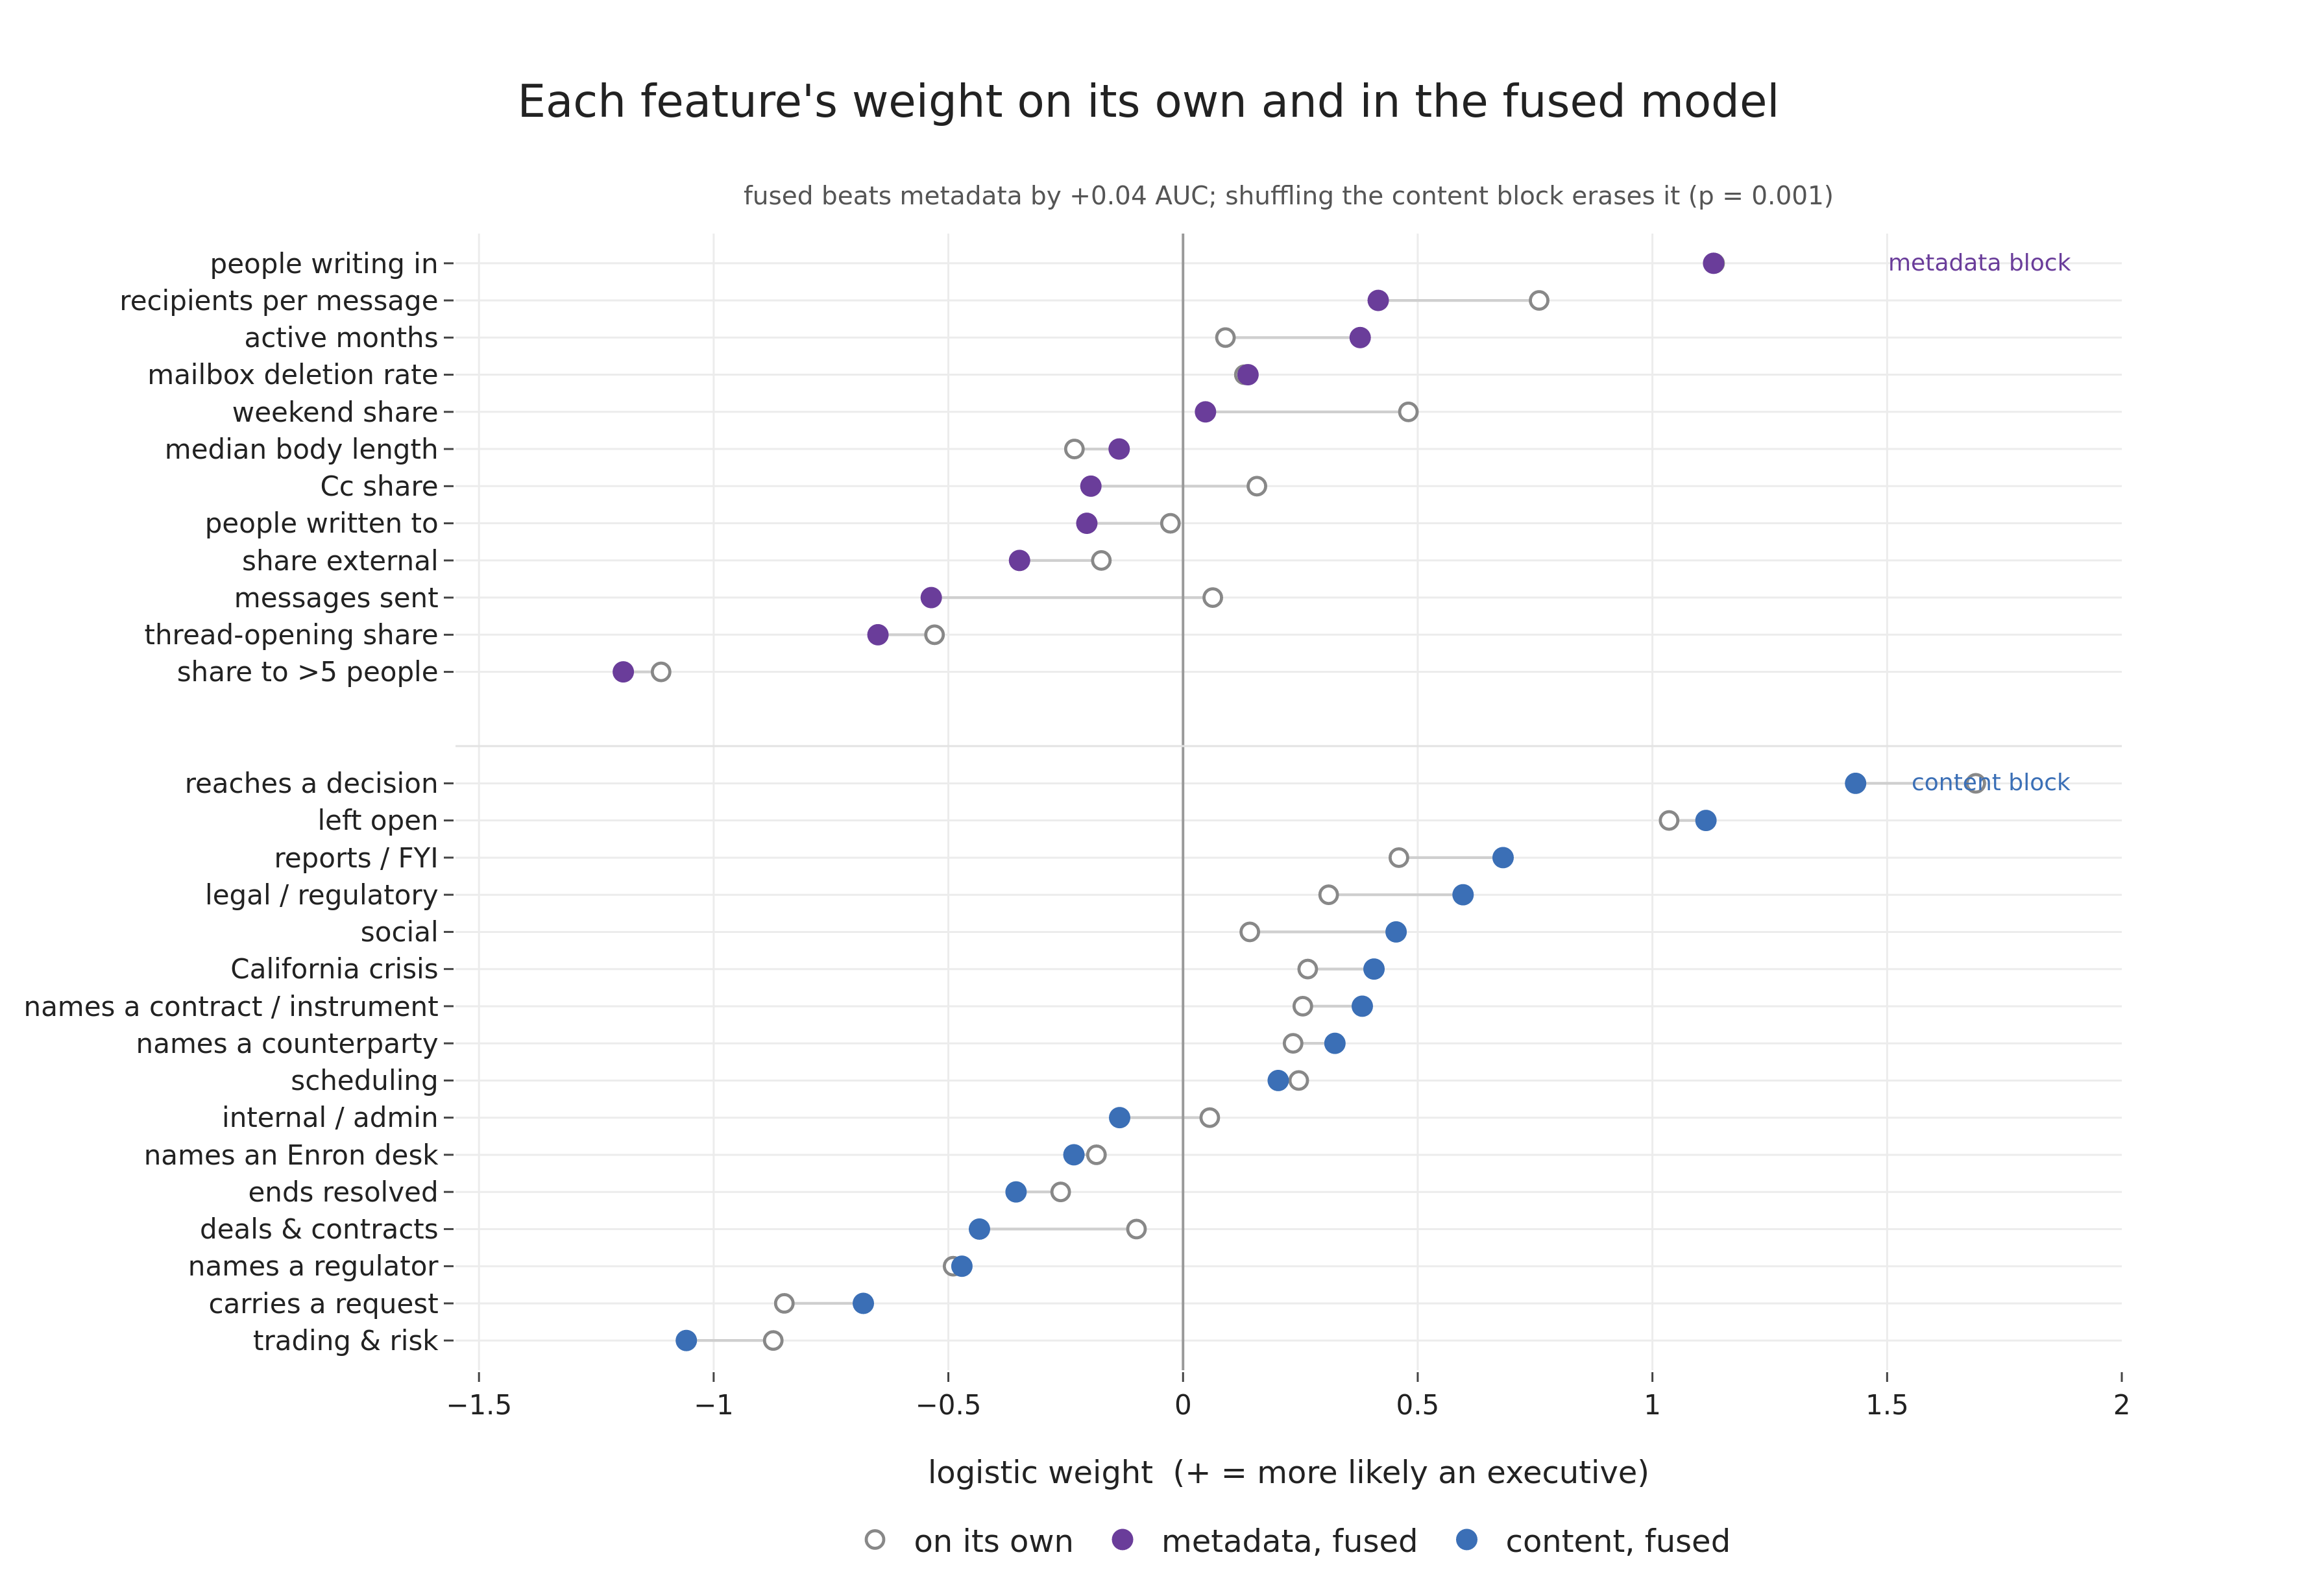

In [4]:
fold = StratifiedKFold(10, shuffle=True, random_state=0)
def oof_auc_fixed(X, y):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
    return roc_auc_score(y, cross_val_predict(clf, X, y, cv=fold, method="predict_proba")[:, 1])
auc_m = oof_auc_fixed(Xm, y_exec)
delta_obs = oof_auc_fixed(Xf, y_exec) - auc_m
rng = np.random.default_rng(7)
NP = 1000
dnull = np.empty(NP)
for i in range(NP):
    dnull[i] = oof_auc_fixed(np.hstack([Xm, Xc[rng.permutation(len(common))]]), y_exec) - auc_m
p_delta = (int(np.sum(dnull >= delta_obs)) + 1) / (NP + 1)
print(f"metadata {auc_m:.3f}  fused {auc_m + delta_obs:.3f}  gain {delta_obs:+.3f}")
print(f"shuffled-content gain: mean {dnull.mean():+.3f}, sd {dnull.std():.3f}  ->  p = {p_delta:.4f}")

def fit_w(X, feats):
    return pd.Series(LogisticRegression(max_iter=5000, class_weight="balanced")
                     .fit(StandardScaler().fit_transform(X), y_exec).coef_[0], index=feats)
w_m_solo, w_c_solo = fit_w(Xm, META_FEATS), fit_w(Xc, CONTENT_FEATS)
wf = fit_w(Xf, META_FEATS + CONTENT_FEATS)
w_m_fused, w_c_fused = wf[META_FEATS], wf[CONTENT_FEATS]

# stack content block (bottom) then a gap then metadata block (top), each sorted by fused weight
c_ord = list(w_c_fused.sort_values().index)
m_ord = list(w_m_fused.sort_values().index)
GAP = 2.0
ypos, solo, fused, blkcol = {}, {}, {}, {}
for i, f in enumerate(c_ord):
    ypos[f] = i; solo[f] = w_c_solo[f]; fused[f] = w_c_fused[f]; blkcol[f] = BLUE
for i, f in enumerate(m_ord):
    ypos[f] = len(c_ord) + GAP + i; solo[f] = w_m_solo[f]; fused[f] = w_m_fused[f]; blkcol[f] = PURPLE
allf = c_ord + m_ord

lx, ly = [], []
for f in allf:
    lx += [solo[f], fused[f], None]; ly += [ypos[f], ypos[f], None]
fig = go.Figure()
fig.add_trace(go.Scatter(x=lx, y=ly, mode="lines", line=dict(color="#cfcfcf", width=1.4),
    hoverinfo="skip", showlegend=False))
fig.add_trace(go.Scatter(x=[solo[f] for f in allf], y=[ypos[f] for f in allf], mode="markers",
    name="on its own", marker=dict(size=9, color="white", line=dict(color="#888", width=1.6))))
fig.add_trace(go.Scatter(x=[fused[f] for f in m_ord], y=[ypos[f] for f in m_ord], mode="markers",
    name="metadata, fused", marker=dict(size=11, color=PURPLE)))
fig.add_trace(go.Scatter(x=[fused[f] for f in c_ord], y=[ypos[f] for f in c_ord], mode="markers",
    name="content, fused", marker=dict(size=11, color=BLUE)))
fig.add_vline(x=0, line=dict(color="#999", width=1.3))
ysep = len(c_ord) - 1 + GAP / 2
fig.add_hline(y=ysep, line=dict(color="#e3e3e3", width=1))
fig.add_annotation(x=1.9, y=ypos[m_ord[-1]], text="metadata block", showarrow=False, xanchor="right",
    font=dict(size=12, color=PURPLE))
fig.add_annotation(x=1.9, y=ypos[c_ord[-1]], text="content block", showarrow=False, xanchor="right",
    font=dict(size=12, color=BLUE))
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=1.05, xanchor="center", showarrow=False,
    text=f"fused beats metadata by {delta_obs:+.02f} AUC; shuffling the content block erases it "
         f"(p = {p_delta:.3f})", font=dict(size=13, color="#555"))
fig.update_xaxes(title_text="logistic weight  (+ = more likely an executive)", range=[-1.55, 2.0])
fig.update_yaxes(tickvals=[ypos[f] for f in allf], ticktext=[PRETTY[f] for f in allf],
                 range=[-0.8, ypos[m_ord[-1]] + 0.8])
fig.update_layout(title="Each feature's weight on its own and in the fused model",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.12, yanchor="top"))
save_fig(fig, "f2_content_adds.png", w=1180, h=820, margin=dict(l=215, r=90, t=120, b=90))

The gain of about four AUC points clears the shuffled-content null cleanly (p
around 0.001), and the weights show why. The strongest signal in each window
barely moves between its solo dot and its fused dot: the number of distinct
people writing in stays near +1.1 on the metadata side, and on the content side
the decision weight stays high, the open-thread weight holds, and the negative
trading weight holds. Those are the signals each window owns, and they survive
the merge, which is what lets the fused model clear both solos. The dots that
slide toward zero are the weaker, shared features (raw send volume, weekend
timing, Cc rate), the ones the other window already explains. The content the
metadata never had is the decision axis: an executive sits in threads that settle
or hold open questions, in legal and reporting traffic, while requests and
trading mark everyone below.

## Who the fused model places, and who it misses

Seniority is predicted as a regression on the one-to-seven title scale, so each
out-of-fold estimate is a real number; a person who reads as half director and
half managing-director comes out near 3.5. Rounding to the nearest of the seven
ranks turns that into a predicted rank, and the chart counts how many people fall
in each true-rank-by-predicted-rank cell. Both axes are the seven ranks exactly,
so every bubble sits on the grid and its size is the headcount. The dashed line
is a perfect call; bubbles below it are people placed too junior, above it too
senior. The Spearman in the corner is computed on the unrounded estimate.

fused seniority: Spearman 0.515; snapped exact 18%, within one rank 70%


/tmp/ipykernel_1513829/586013317.py:40: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


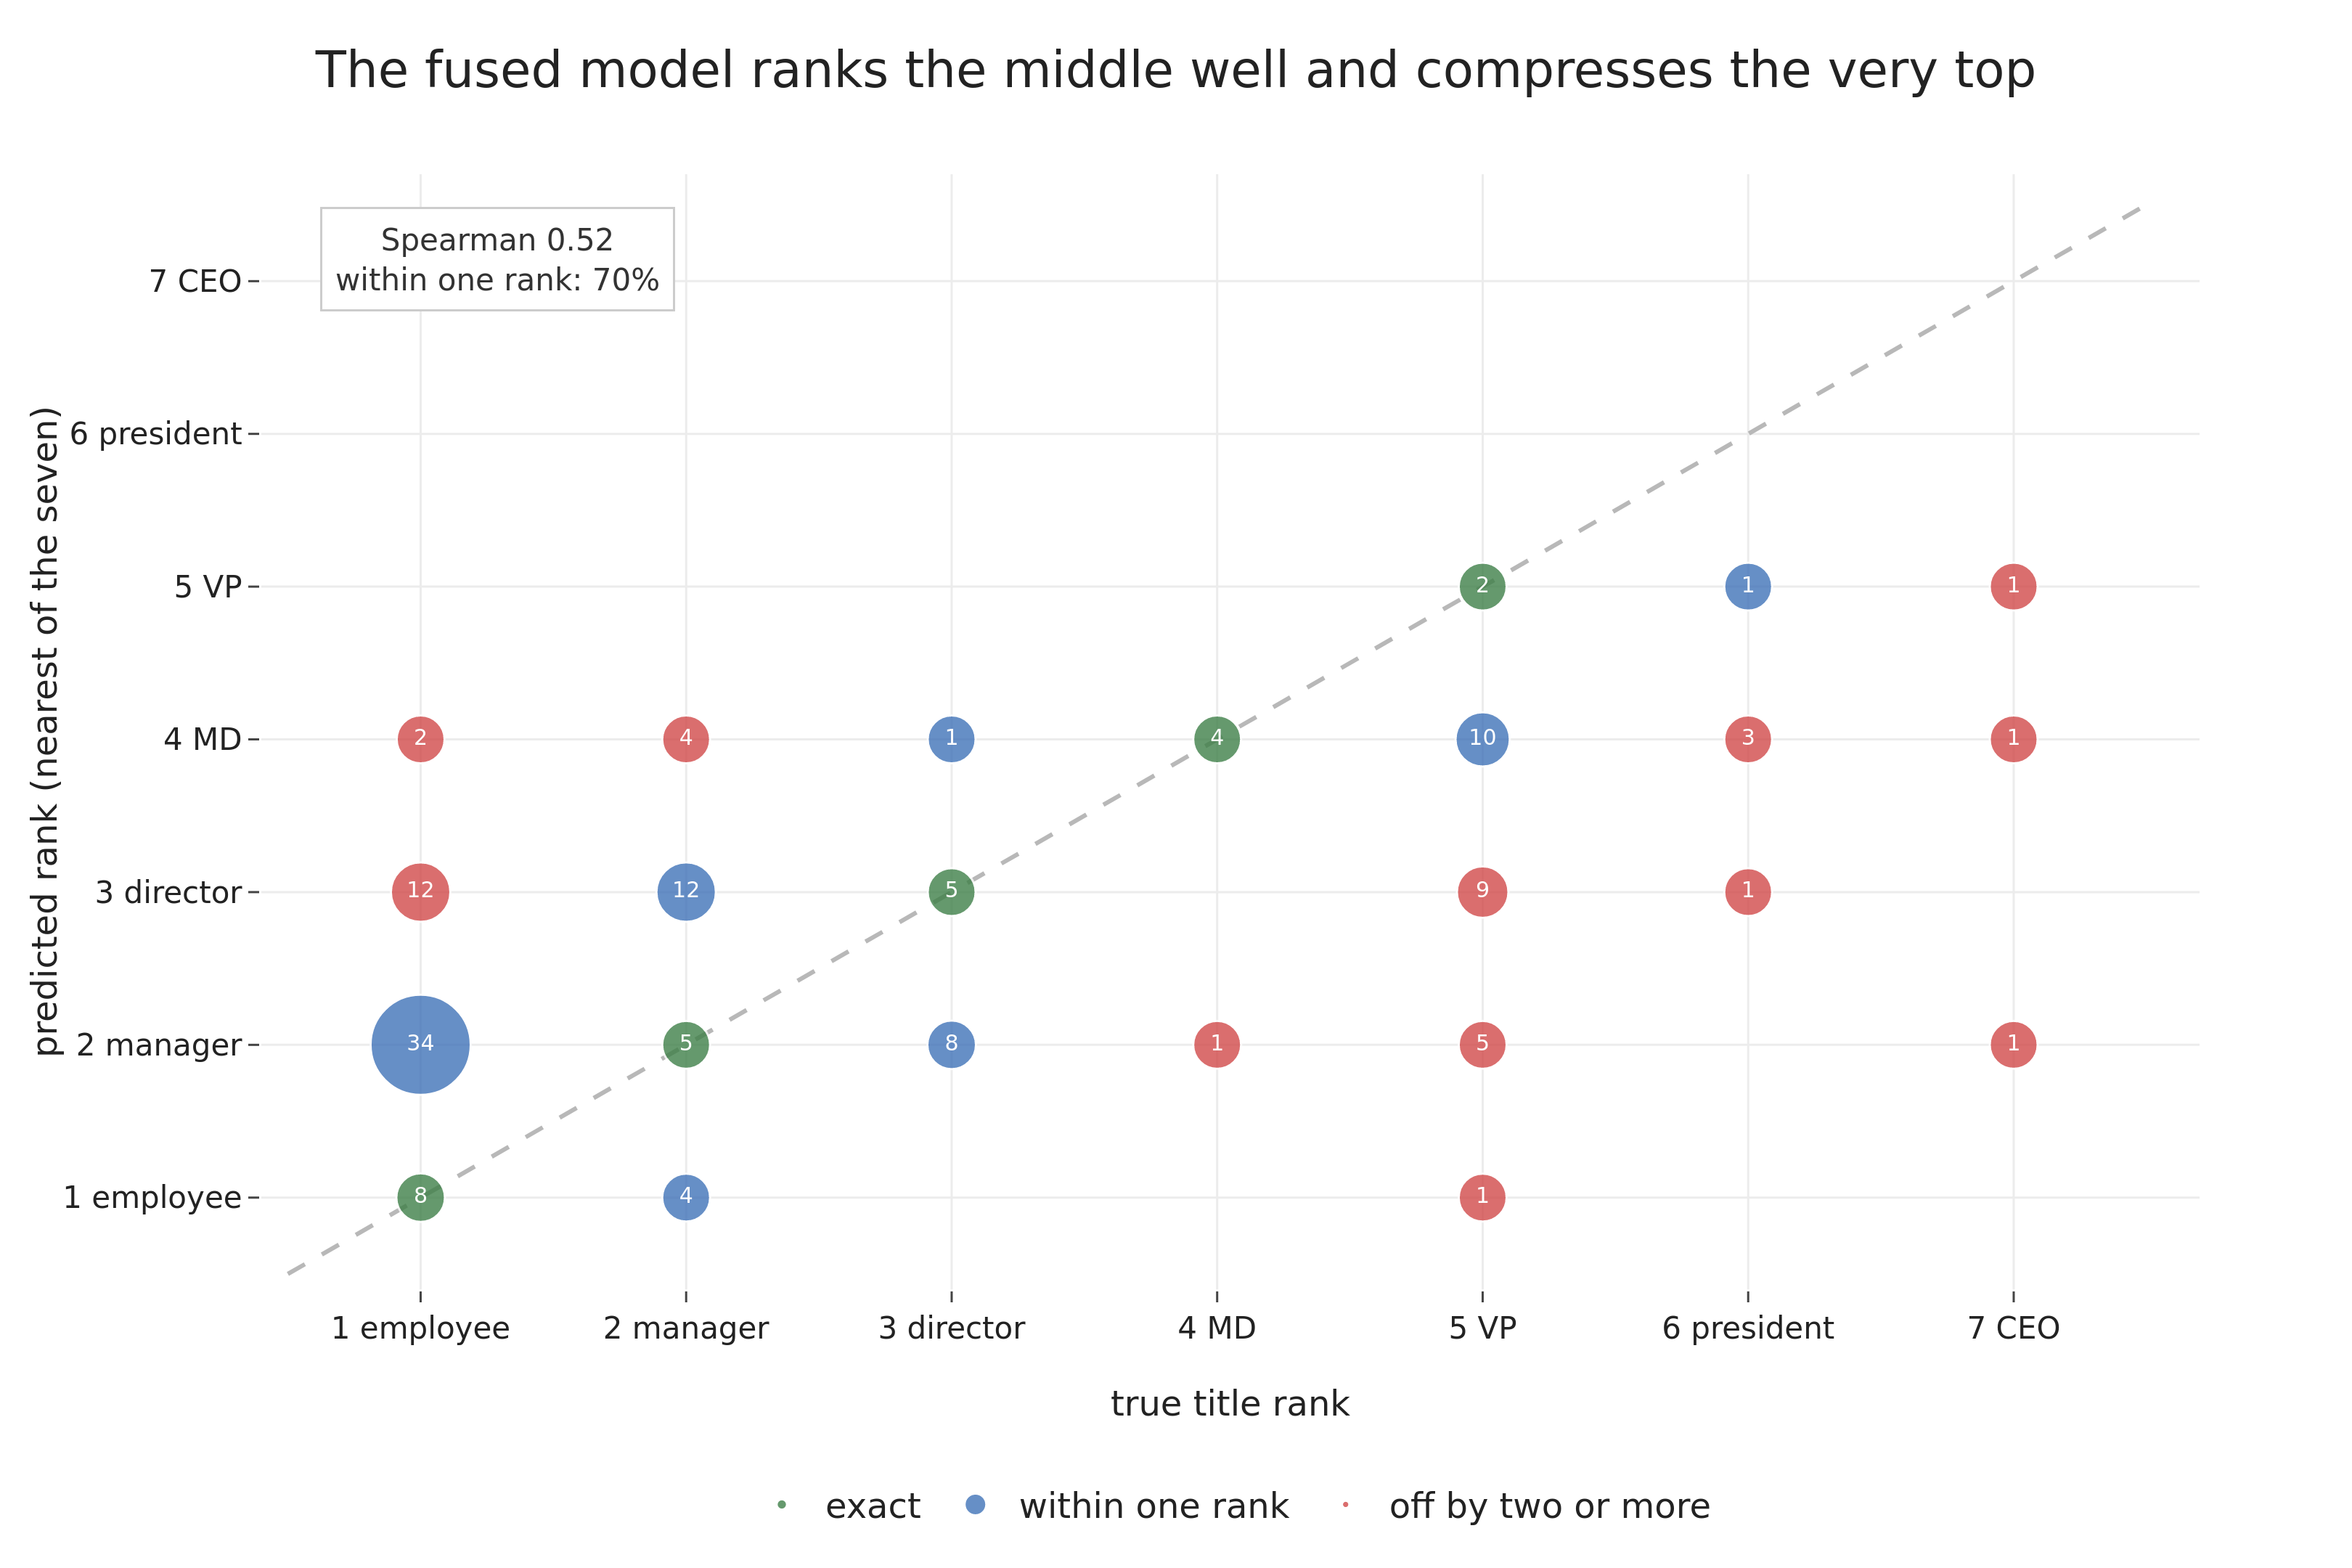

In [5]:
import collections
pred_rank = cross_val_predict(make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20))),
                              Xf, y_rank, cv=KFold(10, shuffle=True, random_state=0))
rho_f = spearmanr(y_rank, pred_rank).statistic
yr = y_rank.astype(int)
pred_snap = np.clip(np.rint(pred_rank), 1, 7).astype(int)
within1 = float(np.mean(np.abs(pred_snap - yr) <= 1))
exact = float(np.mean(pred_snap == yr))
print(f"fused seniority: Spearman {rho_f:.3f}; snapped exact {exact:.0%}, within one rank {within1:.0%}")

cells = collections.Counter(zip(yr.tolist(), pred_snap.tolist()))
maxn = max(cells.values())
RANKLAB = {1: "1 employee", 2: "2 manager", 3: "3 director", 4: "4 MD",
           5: "5 VP", 6: "6 president", 7: "7 CEO"}
fig = go.Figure()
fig.add_trace(go.Scatter(x=[0.5, 7.5], y=[0.5, 7.5], mode="lines",
    line=dict(color=GREY, dash="dash", width=2), showlegend=False, hoverinfo="skip"))
for d, nm, col in [(0, "exact", GREEN), (1, "within one rank", BLUE), (2, "off by two or more", RED)]:
    pts = [(t, p, n) for (t, p), n in cells.items() if (abs(t - p) == d if d < 2 else abs(t - p) >= 2)]
    if not pts:
        continue
    fig.add_trace(go.Scatter(x=[t for t, p, n in pts], y=[p for t, p, n in pts], mode="markers+text", name=nm,
        marker=dict(size=[n for t, p, n in pts], sizemode="area", sizeref=2.0 * maxn / (46.0 ** 2), sizemin=11,
                    color=col, opacity=0.78, line=dict(color="white", width=1)),
        text=[str(n) for t, p, n in pts], textposition="middle center", textfont=dict(size=10, color="white")))
fig.update_xaxes(title_text="true title rank", tickvals=list(RANKLAB), ticktext=list(RANKLAB.values()),
                 range=[0.4, 7.7])
fig.update_yaxes(title_text="predicted rank (nearest of the seven)", tickvals=list(RANKLAB),
                 ticktext=list(RANKLAB.values()), range=[0.4, 7.7])
fig.add_annotation(xref="paper", yref="paper", x=0.03, y=0.97, showarrow=False, xanchor="left",
    text=f"Spearman {rho_f:.2f}<br>within one rank: {within1:.0%}", font=dict(size=14, color="#333"),
    bordercolor="#ccc", borderwidth=1, borderpad=6, bgcolor="white")
fig.update_layout(title="The fused model ranks the middle well and compresses the very top",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.16, yanchor="top"))
save_fig(fig, "f3_seniority_map.png", w=1080, h=720, margin=dict(l=120, r=70, t=80, b=110))

The model orders the bulk of the ladder sensibly: the green and blue bubbles,
exact and within-one calls, cluster on and beside the diagonal through the middle
ranks. The red bubbles sit in the lower right, where the senior people are. The
top of the title ladder, the presidents and the two CEOs in the corpus (Skilling
and Delainey among them), is pulled down toward the managing-director and VP
bands, and the predicted axis never reaches six or seven at all. With only a
dozen people above vice president and a regression that pays for large errors,
the model keeps its guesses near the middle. It recovers the gradient and the
executive boundary; the precise top of the hierarchy stays beyond what either
window carries.

## What pred-3 adds

The two pred-2 windows are not redundant. For the binary executive call they
carry partly separate signal, and joining them lifts the out-of-fold AUC from
about 0.79 to 0.83, a gain that survives shuffling the content block (p around
0.001). The content half of that gain is an axis the metadata cannot see: who
sits in the threads that decide and oversee. For the fine ordinal rank the
picture is different. Metadata already reaches a rank correlation near 0.49 and
content adds nothing measurable, and the fused model, like its parts, recovers
the middle of the hierarchy while compressing the few people at the very top.